# Data Loading and Prep

In [178]:
import os
import pandas as pd
import pickle as pkl
import numpy as np

from itertools import combinations

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference

from scipy.stats import zscore

import mygene

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

SAVE = True

if SAVE:
    OUTPUT_PATH = '/Users/nick/projects/bioinformatics-project/results/deseq'
    os.makedirs(OUTPUT_PATH, exist_ok=True)

# Import data
df_metadata = pd.read_csv('/Users/nick/projects/bioinformatics-project/data/processed/metadata.csv', index_col=0)
df_expression = pd.read_csv('/Users/nick/projects/bioinformatics-project/data/processed/expression.csv', index_col=0)

# Validate and describe data
if df_expression.shape[0] == df_metadata.shape[0]:
    print('Samples:', df_expression.shape[0])
else:
    print('Error!!! The expression and metadata data sources do not contain the same number of samples')
print('Genes:', df_expression.shape[1])
print('Metadata Features:', df_metadata.shape[1])

# Data prep
# Undo normalization (source data has been log transformed)
df_expression_rawcounts = (2**df_expression) - 1
df_expression_rawcounts = df_expression_rawcounts.astype(int)

# Filter genes with less than 10 samples with less than 10 reads (consistent with notebook 02)
df_expression_rawcounts_filtered = df_expression_rawcounts[df_expression_rawcounts.columns[(df_expression_rawcounts >= 15).sum(axis=0) >= 15]]
print(df_expression_rawcounts_filtered.shape[1], 'genes left after filtering')

# Match indexes of the metadata and expression raw counts after filtering (for anndata)
df_metadata = df_metadata.loc[df_expression_rawcounts_filtered.index]

Samples: 546
Genes: 60660
Metadata Features: 88
27516 genes left after filtering


In [160]:
# Normalize data with VST for later (Heatmap)
# Setup dataset for Deseq
dds = DeseqDataSet(
    counts=df_expression_rawcounts_filtered,
    metadata=df_metadata,
    design='~PAM50'
)

# Run VST
dds.vst()

# Save as dataframe
df_expression_vst = pd.DataFrame(dds.layers['vst_counts'])

# Deseq VST produces numpy array, destroying axis labels, reset them
df_expression_vst.columns = df_expression_rawcounts_filtered.columns
df_expression_vst.index = df_expression_rawcounts_filtered.index

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.25 seconds.

Fitting dispersions...
... done in 2.73 seconds.



# Run Deseq

In [96]:
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=df_expression_rawcounts_filtered,
    metadata=df_metadata,
    design='~PAM50',
    refit_cooks=True,
    inference=inference
)
dds.deseq2()

if SAVE:
    with open(os.path.join(OUTPUT_PATH, "dds.pkl"), "wb") as f:
        pkl.dump(dds, f)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.23 seconds.

Fitting dispersions...
... done in 4.54 seconds.

Fitting dispersion trend curve...
... done in 0.22 seconds.

Fitting MAP dispersions...
... done in 4.93 seconds.

Fitting LFCs...
... done in 2.53 seconds.

Calculating cook's distance...
... done in 0.59 seconds.

Replacing 2265 outlier genes.

Fitting dispersions...
... done in 0.34 seconds.

Fitting MAP dispersions...
... done in 0.34 seconds.

Fitting LFCs...
... done in 0.48 seconds.



In [97]:
subtypes = df_metadata['PAM50'].unique().tolist()
print(subtypes)

['Basal', 'Her2', 'LumB', 'LumA', 'Normal']


In [98]:
pairs = list(combinations(subtypes, 2))
print(f'{len(pairs)} comparisons to run')

10 comparisons to run


In [99]:
results = {}
for subtype_a, subtype_b in pairs:
    comparison_name = f'{subtype_a}_vs_{subtype_b}'
    print(f'Running: {comparison_name}')

    # Create DeseqStats from model we fit above
    stat_res = DeseqStats(
        dds = dds,
        contrast = ['PAM50', subtype_a, subtype_b],
        inference = inference
    )

    # Get statistical test results
    stat_res.summary()

    # Store results
    results[comparison_name] = stat_res.results_df

print(f"Done! {len(results)} comparisons completed")

Running: Basal_vs_Her2


Running Wald tests...
... done in 0.68 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: PAM50 Basal vs Her2
                       baseMean  log2FoldChange     lfcSE      stat  \
ENSG00000000003.15  3233.314912        0.526884  0.161815  3.256084   
ENSG00000000005.6     63.975736        1.199678  0.357703  3.353837   
ENSG00000000419.13  2408.941912       -0.125057  0.087307 -1.432393   
ENSG00000000457.14  1613.014263       -0.382883  0.083293 -4.596798   
ENSG00000000460.17   759.984123        0.552309  0.104168  5.302099   
...                         ...             ...       ...       ...   
ENSG00000288658.1     23.138685        0.969054  0.359425  2.696126   
ENSG00000288663.1     25.885746       -0.122187  0.140439 -0.870036   
ENSG00000288670.1    454.104297       -0.165677  0.107050 -1.547662   
ENSG00000288674.1      6.637486        0.245015  0.163116  1.502092   
ENSG00000288675.1     28.282201       -0.343711  0.160202 -2.145489   

                          pvalue          padj  
ENSG00000000003.15  1.129605e-03  2.8846

... done in 0.72 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: PAM50 Basal vs LumB
                       baseMean  log2FoldChange     lfcSE      stat  \
ENSG00000000003.15  3233.314912        1.047525  0.131018  7.995263   
ENSG00000000005.6     63.975736        0.134005  0.287238  0.466531   
ENSG00000000419.13  2408.941912        0.057226  0.070688  0.809555   
ENSG00000000457.14  1613.014263       -0.336307  0.067437 -4.986970   
ENSG00000000460.17   759.984123        0.438661  0.084288  5.204339   
...                         ...             ...       ...       ...   
ENSG00000288658.1     23.138685        0.973613  0.290510  3.351386   
ENSG00000288663.1     25.885746       -0.606499  0.112227 -5.404213   
ENSG00000288670.1    454.104297       -0.217866  0.086638 -2.514681   
ENSG00000288674.1      6.637486        0.146340  0.128792  1.136247   
ENSG00000288675.1     28.282201        0.566653  0.130859  4.330272   

                          pvalue          padj  
ENSG00000000003.15  1.292975e-15  6.9759

...

... done in 0.66 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: PAM50 LumB vs LumA
                       baseMean  log2FoldChange     lfcSE      stat  \
ENSG00000000003.15  3233.314912       -0.650634  0.107080 -6.076138   
ENSG00000000005.6     63.975736       -0.880447  0.234456 -3.755270   
ENSG00000000419.13  2408.941912        0.402476  0.057778  6.965898   
ENSG00000000457.14  1613.014263       -0.075508  0.055085 -1.370748   
ENSG00000000460.17   759.984123        0.531649  0.068947  7.711027   
...                         ...             ...       ...       ...   
ENSG00000288658.1     23.138685        0.935007  0.238722  3.916712   
ENSG00000288663.1     25.885746        0.134576  0.090404  1.488607   
ENSG00000288670.1    454.104297        0.233420  0.070786  3.297540   
ENSG00000288674.1      6.637486        0.033005  0.106164  0.310889   
ENSG00000288675.1     28.282201       -0.281352  0.107526 -2.616584   

                          pvalue          padj  
ENSG00000000003.15  1.231114e-09  1.90204

... done in 0.75 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: PAM50 LumB vs Normal
                       baseMean  log2FoldChange     lfcSE       stat  \
ENSG00000000003.15  3233.314912       -1.110650  0.197596  -5.620825   
ENSG00000000005.6     63.975736       -4.610198  0.430233 -10.715595   
ENSG00000000419.13  2408.941912        0.624446  0.106701   5.852280   
ENSG00000000457.14  1613.014263        0.370840  0.101757   3.644367   
ENSG00000000460.17   759.984123        1.363070  0.127771  10.668076   
...                         ...             ...       ...        ...   
ENSG00000288658.1     23.138685        0.778355  0.442129   1.760472   
ENSG00000288663.1     25.885746       -0.001289  0.167177  -0.007708   
ENSG00000288670.1    454.104297        0.481101  0.130883   3.675818   
ENSG00000288674.1      6.637486       -0.463480  0.189798  -2.441964   
ENSG00000288675.1     28.282201        0.263952  0.201451   1.310253   

                          pvalue          padj  
ENSG00000000003.15  1.90048

... done in 0.73 seconds.



# Analyzing Deseq Results


In [100]:
for name, df in results.items():
    sig = df['padj'] < 0.05
    up = df['log2FoldChange'] > 1 # Higher in first group
    down = df['log2FoldChange'] < -1 # Higher in second group

    n_up = (sig & up).sum()
    n_down = (sig & down).sum()

    # Print significant genes and which group has higher expression
    print(f"{name}: {n_up + n_down} DEGs ({n_up} up, {n_down} down)")

Basal_vs_Her2: 5418 DEGs (3078 up, 2340 down)
Basal_vs_LumB: 6966 DEGs (4041 up, 2925 down)
Basal_vs_LumA: 7531 DEGs (4415 up, 3116 down)
Basal_vs_Normal: 7521 DEGs (3839 up, 3682 down)
Her2_vs_LumB: 3183 DEGs (1756 up, 1427 down)
Her2_vs_LumA: 3953 DEGs (2113 up, 1840 down)
Her2_vs_Normal: 7420 DEGs (3292 up, 4128 down)
LumB_vs_LumA: 1711 DEGs (770 up, 941 down)
LumB_vs_Normal: 7268 DEGs (3076 up, 4192 down)
LumA_vs_Normal: 5319 DEGs (2111 up, 3208 down)


## Volcano Plots

In [151]:
# Volcano Plot Function
def volcano_plot(df, title, ax, labels=None):
    '''
    input:
        - df (pandas df): dataframe used for plotting, output of deseq
        - title (string): title of plot
        - ax: location for plot to be (used in multi-chart plots)
        - labels (list): list of gene symbols for labeling on plot
    output:
    '''
    plot_df = df.dropna(subset=['padj']).copy()
    plot_df['-log10_padj'] = -np.log10(plot_df['padj'])

    conditions = [
        (plot_df['padj'] < 0.05) & (plot_df['log2FoldChange'] > 1),
        (plot_df['padj'] < 0.05) & (plot_df['log2FoldChange'] < -1)
    ]
    category_labels = ['Up', 'Down']

    # Set significant genes as up or down with default as NS
    plot_df['category'] = np.select(conditions, category_labels, default='NS')
    
    # Sort df
    plot_df['category'] = pd.Categorical(
        plot_df['category'],
        categories=['NS', 'Down', 'Up'],
        ordered = True
        )
    plot_df = plot_df.sort_values('category')

    # Set colors for plot
    palette = {
        'NS': 'gray',
        'Up': 'red',
        'Down': 'blue'
    }

    # Define plot
    sns.scatterplot(
          data = plot_df,
          x = 'log2FoldChange',
          y = '-log10_padj',
          hue = 'category',
          palette = palette,
          s = 5,
          alpha = 0.5, # transparency
          edgecolor = 'none',
          ax = ax
      )
    
    # Ax limits
    ax.set_xlim(-10, 10)
    
    # Threshold lines
    ax.axhline(-np.log10(0.05), linestyle = '--', color = 'gray', linewidth = 0.5)
    ax.axvline(1, linestyle = '--', color = 'gray', linewidth = 0.5)
    ax.axvline(-1, linestyle = '--', color = 'gray', linewidth = 0.5)

    # Labels
    ax.set_title(title)
    ax.set_xlabel('') # no per chart label
    ax.set_ylabel('') # no per chart label
    ax.legend().remove()

    # Label points for significant and common genes
    if labels is not None:
        # Filter to only genes to label
        label_df = plot_df[
            plot_df['symbol'].isin(labels) &
            np.isfinite(plot_df['-log10_padj'])
            ]

        texts = []
        for _, row in label_df.iterrows():
            texts.append(ax.annotate(
                row['symbol'],
                xy = (row['log2FoldChange'], row['-log10_padj']),
                fontsize = 6,
                ha = 'center'
            ))

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


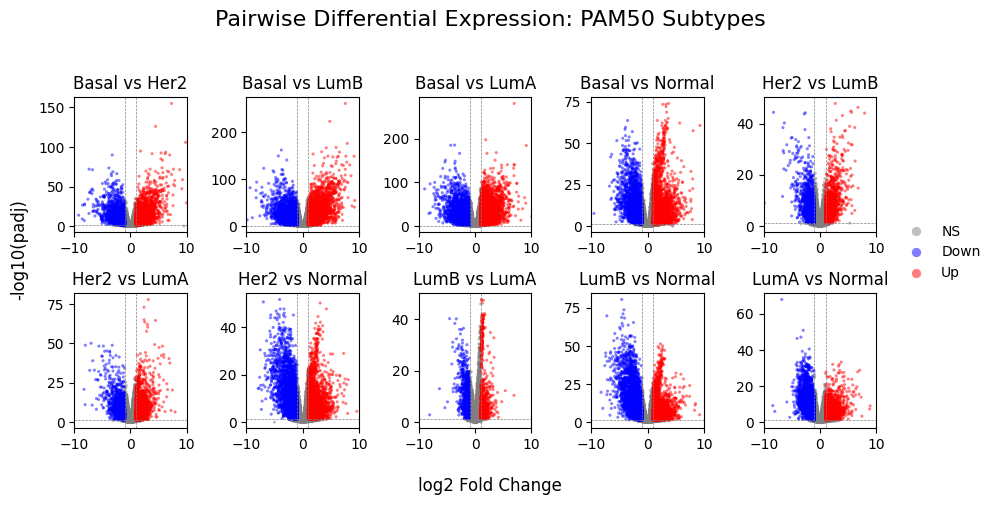

In [152]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))
axes = axes.flatten()

for idx, (name, df) in enumerate(results.items()):
    volcano_plot(df, name.replace('_', ' '), axes[idx])

# Set axis labels
fig.supxlabel('log2 Fold Change')
fig.supylabel('-log10(padj)')

# Figure title
fig.suptitle('Pairwise Differential Expression: PAM50 Subtypes', fontsize = 16)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc = 'center right', markerscale = 3, frameon = False)

# Tight layout with room on the right for the legend
plt.tight_layout(rect=[0, 0, 0.91, 0.95])

# Save figure
fig.savefig(f'{OUTPUT_PATH}/volcano_plots.png', dpi = 150, bbox_inches = 'tight')

In [153]:
normal_comparisons = {k: v for k, v in results.items() if 'Normal' in k}
subtype_comparisons = {k: v for k, v in results.items() if 'Normal' not in k}

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


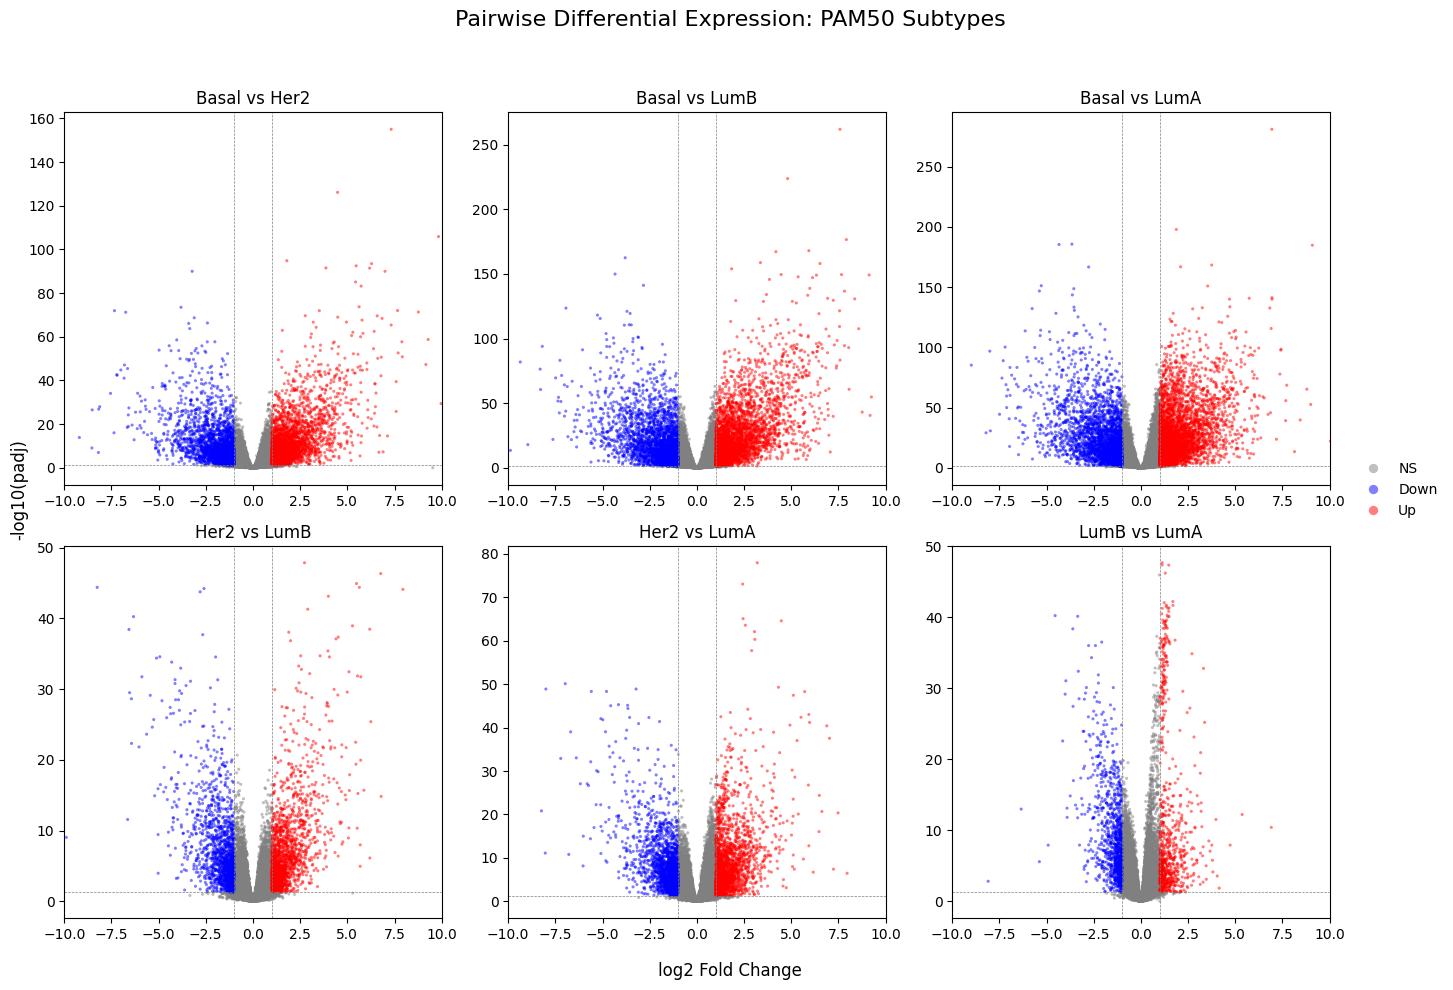

In [154]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, (name, df) in enumerate(subtype_comparisons.items()):
    volcano_plot(df, name.replace('_', ' '), axes[idx])
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.98,
0.5), markerscale=3, frameon=False)
fig.suptitle('Pairwise Differential Expression: PAM50 Subtypes',
fontsize=16)
fig.supxlabel('log2 Fold Change')
fig.supylabel('-log10(padj)')
plt.tight_layout(rect=[0, 0, 0.92, 0.95])
fig.savefig(f'{OUTPUT_PATH}/subtype_volcano_plots.png', dpi = 150, bbox_inches = 'tight')

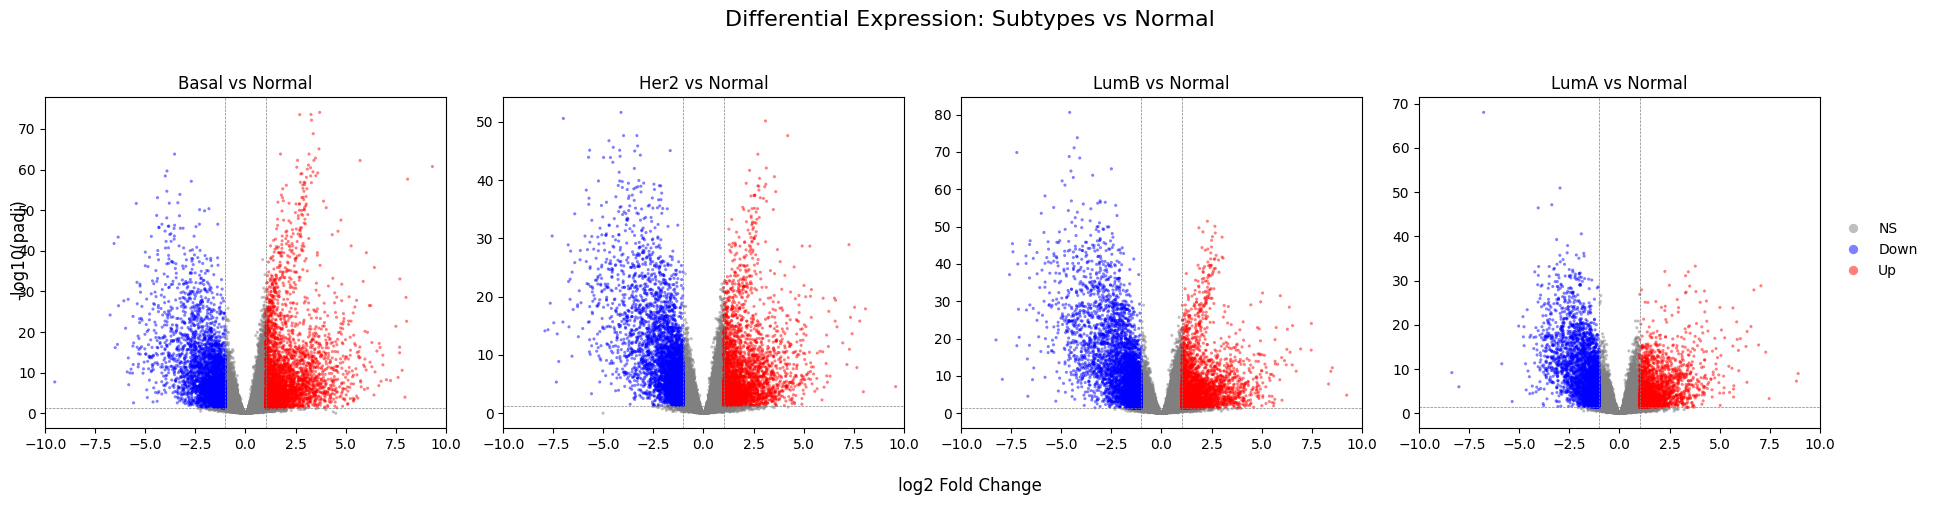

In [155]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, (name, df) in enumerate(normal_comparisons.items()):
    volcano_plot(df, name.replace('_', ' '), axes[idx])
handles, labels = axes[0].get_legend_handles_labels()

# Legend
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.98, 0.5), markerscale=3, frameon=False)

# Labels
fig.suptitle('Differential Expression: Subtypes vs Normal', fontsize=16)
fig.supxlabel('log2 Fold Change')
fig.supylabel('-log10(padj)')

# Layout
plt.tight_layout(rect=[0, 0, 0.94, 0.95])

# Save
fig.savefig(f'{OUTPUT_PATH}/normal_volcano_plots.png', dpi = 150, bbox_inches = 'tight')

In [124]:
mg = mygene.MyGeneInfo()

# Get genes and clean to remove version of ensembl id
gene_ids = results['Basal_vs_LumA'].index.tolist()
gene_ids_clean = [g.split('.')[0] for g in gene_ids]

# Query using cleaned id
query_results = mg.querymany(gene_ids_clean,
    scopes = 'ensembl.gene',
    fields = 'symbol',
    species = 'human'
    )

# Make gene df
df_genes = pd.DataFrame({
    'gene_id': gene_ids,
    'gene_id_clean': gene_ids_clean
})

df_genes = df_genes.set_index('gene_id')

# Map gene_id_clean to symbol
clean_to_symbol = {r['query']: r.get('symbol', r['query']) for r in query_results}

# Add symbol to df
df_genes['symbol'] = df_genes['gene_id_clean'].map(clean_to_symbol)

# Save df (note: this currently only captures the filtered set of genes ~27k rather than the total ~61k)
# All analysis have been done with this filtered set of genes, so this should be fine
df_genes.to_csv('/Users/nick/projects/bioinformatics-project/data/processed/gene_map.csv')

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
12 input query terms found dup hits:	[('ENSG00000175711', 2), ('ENSG00000215156', 2), ('ENSG00000226519', 2), ('ENSG00000227110', 2), ('E
474 input query terms found no hit:	['ENSG00000002079', 'ENSG00000112096', 'ENSG00000130723', 'ENSG00000146521', 'ENSG00000148362', 'ENS


In [125]:
# Add symbols to all result dfs
for name, df in results.items():
    df['symbol'] = df_genes['symbol']

markers = ['ESR1', 'PGR', 'ERBB2', 'KRT5', 'KRT14', 'KRT17', 'FOXA1', 'GATA3']
df = results['Basal_vs_LumA']
df[df['symbol'].isin(markers)][['symbol', 'log2FoldChange', 'padj']].sort_values('padj')

,symbol,log2FoldChange,padj
ENSG00000129514.8,FOXA1,-3.631757,3.204569e-144
ENSG00000082175.15,PGR,-5.763095,6.794771e-133
ENSG00000107485.18,GATA3,-3.022840,4.462979e-119
ENSG00000091831.24,ESR1,-4.140387,1.673912e-106
ENSG00000128422.17,KRT17,2.096835,1.062738e-18
ENSG00000186081.12,KRT5,1.884330,3.291317e-12
ENSG00000186847.6,KRT14,1.710441,3.059239e-10
ENSG00000141736.14,ERBB2,-0.741556,1.394401e-06


In [129]:
def get_labels(df, n_top=5, known_markers=None):
    if known_markers is None:
        known_markers = ['ESR1', 'PGR', 'ERBB2', 'KRT5', 'KRT14', 'FOXA1', 'GATA3']

    sig = df[(df['padj'] < 0.05) & (df['log2FoldChange'].abs() > 1)]

    # Top N most significant
    top_genes = set(sig.sort_values('padj').head(n_top)['symbol'].dropna())

    # Known markers that are significant in this comparison
    known_sig = set(sig[sig['symbol'].isin(known_markers)]['symbol'].dropna())

    # Combine without duplicates
    return top_genes | known_sig

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


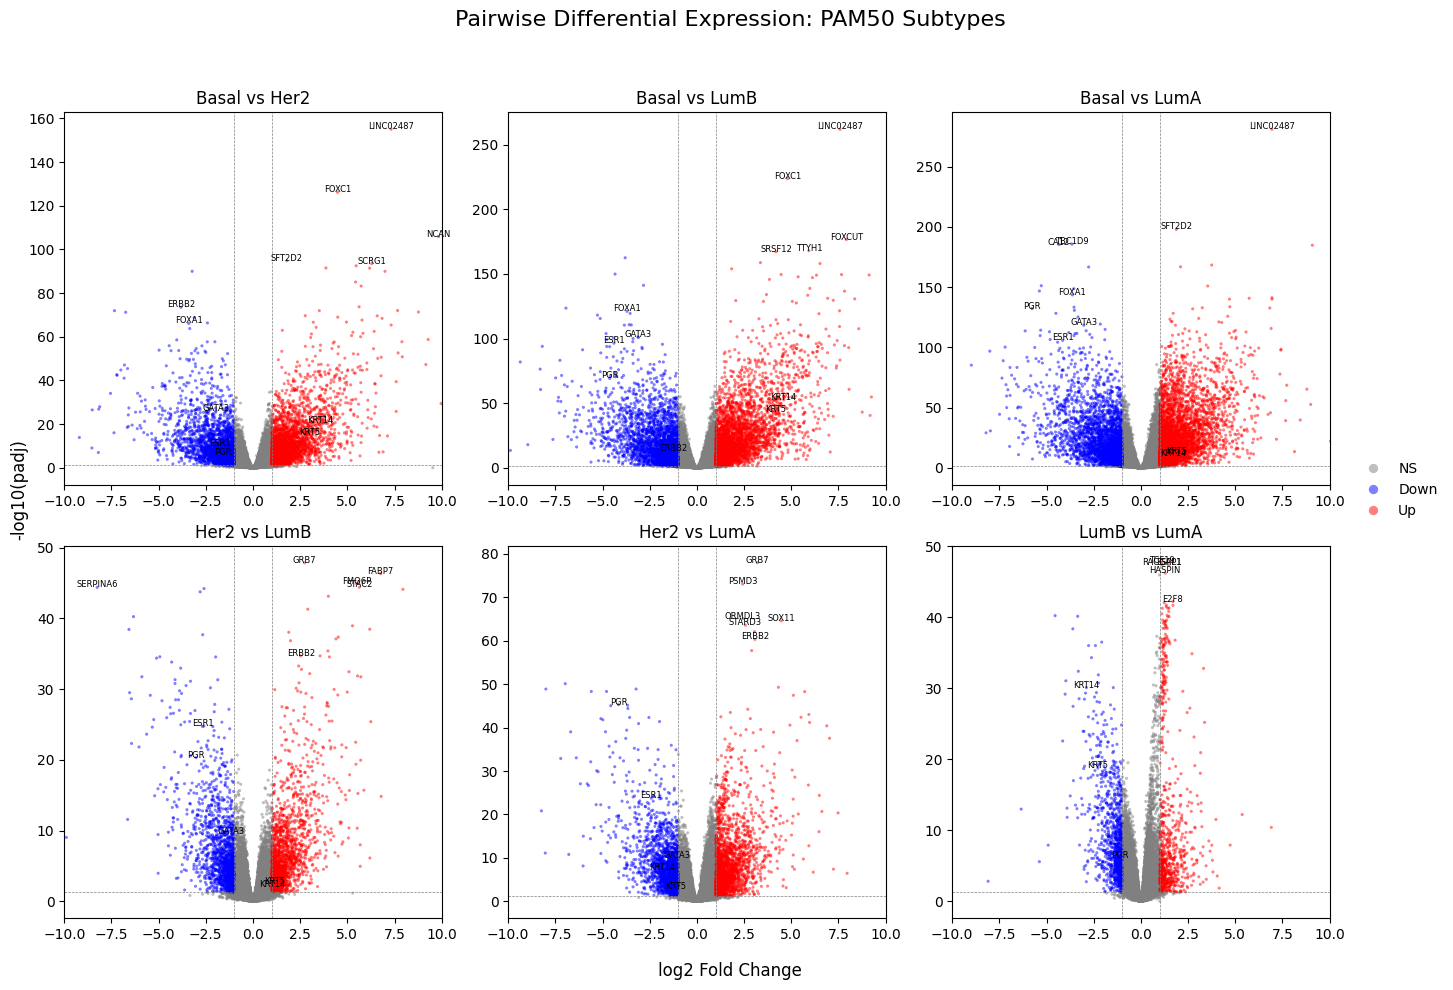

In [156]:
known_markers = ['ESR1', 'PGR', 'ERBB2', 'KRT5', 'KRT14', 'FOXA1', 'GATA3']

# Subtype comparisons with point labels
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, (name, df) in enumerate(subtype_comparisons.items()):
    labels = get_labels(df, n_top=5, known_markers=known_markers)
    volcano_plot(df, name.replace('_', ' '), axes[idx], labels=labels)

handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='center right', bbox_to_anchor=(0.98, 0.5), markerscale=3, frameon=False)
fig.suptitle('Pairwise Differential Expression: PAM50 Subtypes', fontsize=16)
fig.supxlabel('log2 Fold Change')
fig.supylabel('-log10(padj)')
plt.tight_layout(rect=[0, 0, 0.92, 0.95])
fig.savefig(f'{OUTPUT_PATH}/subtype_volcano_plots_labeled.png', dpi=150, bbox_inches='tight')


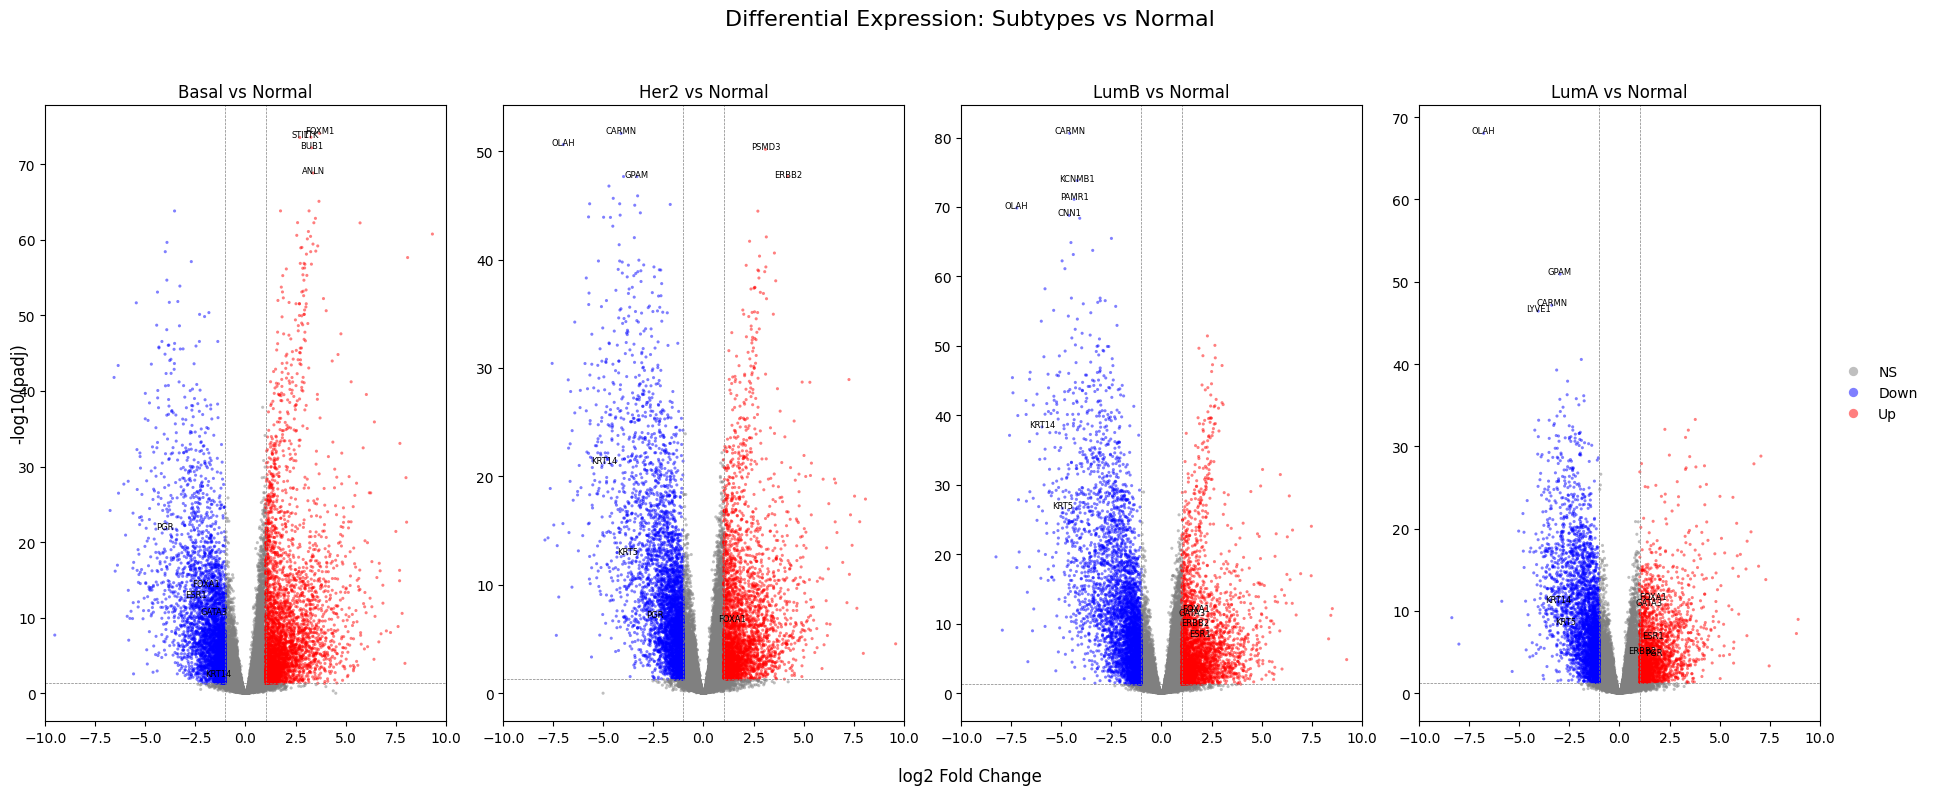

In [157]:
# Normal comparisons with point labels
fig, axes = plt.subplots(1, 4, figsize=(20, 8))
for idx, (name, df) in enumerate(normal_comparisons.items()):
    labels = get_labels(df, n_top=5, known_markers=known_markers)
    volcano_plot(df, name.replace('_', ' '), axes[idx], labels=labels)

handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='center right', bbox_to_anchor=(0.98, 0.5), markerscale=3, frameon=False)
fig.suptitle('Differential Expression: Subtypes vs Normal', fontsize=16)
fig.supxlabel('log2 Fold Change')
fig.supylabel('-log10(padj)')
plt.tight_layout(rect=[0, 0, 0.94, 0.95])
fig.savefig(f'{OUTPUT_PATH}/normal_volcano_plots_labeled.png', dpi=150, bbox_inches='tight')

# Heatmap

In [161]:
df_expression_vst.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288605.1,ENSG00000288610.1,ENSG00000288611.1,ENSG00000288612.1,ENSG00000288648.1,ENSG00000288658.1,ENSG00000288663.1,ENSG00000288670.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-AN-A0FL-01A,14.369153,3.792209,11.508052,10.205012,8.902183,7.908425,9.628038,11.253235,12.024214,11.847228,...,7.537174,2.538868,3.277367,6.000194,2.538868,4.942809,4.942809,8.547457,3.277367,6.287442
TCGA-A1-A0SK-01A,12.476283,2.538868,11.639705,9.756873,10.116645,6.841566,8.731255,10.646541,10.868361,12.067176,...,3.327907,3.764834,8.728226,4.669186,3.100235,5.078524,4.064589,8.081018,3.499485,4.557921
TCGA-BH-A0HL-01A,7.996603,4.022344,12.995741,10.044326,8.701749,6.090059,9.055452,10.564568,10.746613,11.355810,...,3.471536,3.471536,4.808329,5.629245,3.304695,3.471536,5.578804,8.590059,4.022344,5.499564
TCGA-BH-A0HN-01A,9.857316,2.538868,11.032867,10.971221,8.762212,9.189963,7.992214,11.007335,11.158625,10.919513,...,2.538868,2.538868,2.538868,6.452351,2.538868,4.308380,6.196900,8.942995,4.308380,6.049666
TCGA-BH-A0E0-01A,12.331665,6.111992,11.744772,11.389566,10.738961,10.746595,9.912394,11.157290,10.810633,12.388396,...,2.538868,3.334665,4.240588,5.768900,2.538868,3.885364,3.885364,9.825673,2.538868,5.096382


In [243]:
def plot_heatmap(results_df, df_vst, df_metadata, title, n_top=50):
    # Get top genes from deseq results
    top_genes = results_df.sort_values('padj').head(n_top).index
    # Select those genes from VST normalized raw data, then make genes rows
    heatmap_data = df_vst[top_genes].T
    # Z-score each gene
    heatmap_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)    
    
    # Sort by subtype
    sample_order = df_metadata.loc[heatmap_z.columns, 'PAM50'].sort_values().index
    heatmap_z = heatmap_z[sample_order]
    
    # Colors
    subtype_colors = {
        'Basal': 'red',
        'Her2': 'purple',
        'LumA': 'blue',
        'LumB': 'lightblue',
        'Normal': 'green'
    }
    col_colors = df_metadata.loc[heatmap_z.columns, 'PAM50'].map(subtype_colors).to_numpy()

    # Replace ensemble IDs with gene symbols
    row_labels = heatmap_z.index.map(lambda x: df_genes.loc[x, 'symbol'] if x in df_genes.index else x)
    heatmap_z.index = row_labels

    # Plot
    g = sns.clustermap(
        heatmap_z,
        cmap = 'RdBu_r',
        center = 0,
        col_colors = col_colors,
        row_cluster = True,
        col_cluster = False,
        figsize = (12, 8),
        yticklabels = True,
        xticklabels = False,
        cbar_pos = None, # manually add color bar
        dendrogram_ratio=(0.1, 0)
    )
    
    # Plot labels
    g.fig.suptitle(f'Top {n_top} DEGs from {title} Comparison', y = 1.05, fontsize = 14)
    g.fig.text(0.5, 1.0, 'Expression (VST normalized, z-scored by gene)', ha = 'center', fontsize = 10, style = 'italic')
    g.ax_heatmap.set_xlabel('')
    g.ax_heatmap.set_ylabel('')
    
    # Add color bar
    cbar_ax = g.fig.add_axes([1, 0.55, 0.02, 0.2])  # [left, bottom, width, height]
    g.fig.colorbar(g.ax_heatmap.collections[0], cax=cbar_ax)

    # Add legend
    legend_patches = [Patch(color=color, label=subtype) for subtype, color in subtype_colors.items()]
    g.ax_heatmap.legend(
      handles=legend_patches,
      loc='center left',
      bbox_to_anchor=(1.15, 0.45),
      frameon=False,
      title='Subtype'
    )

    return g

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


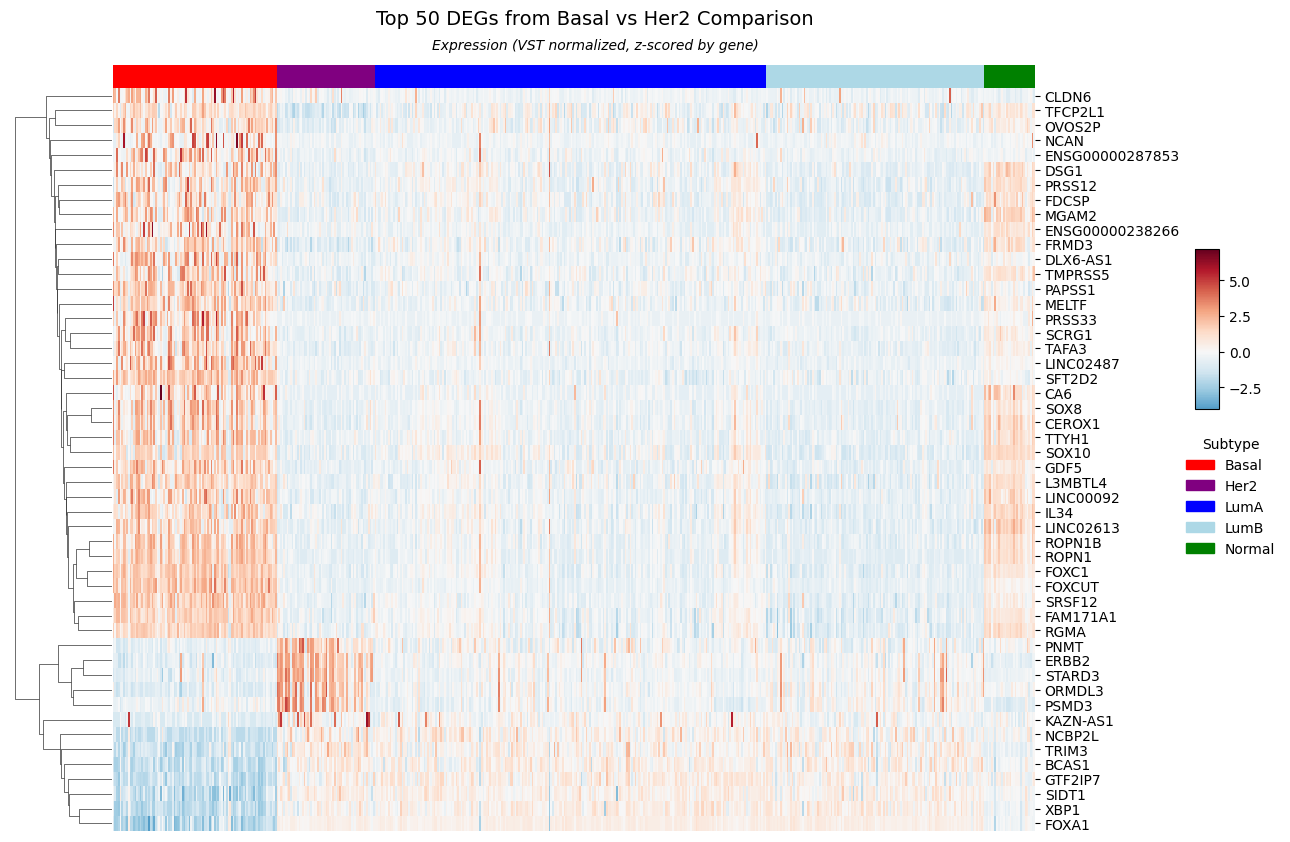

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


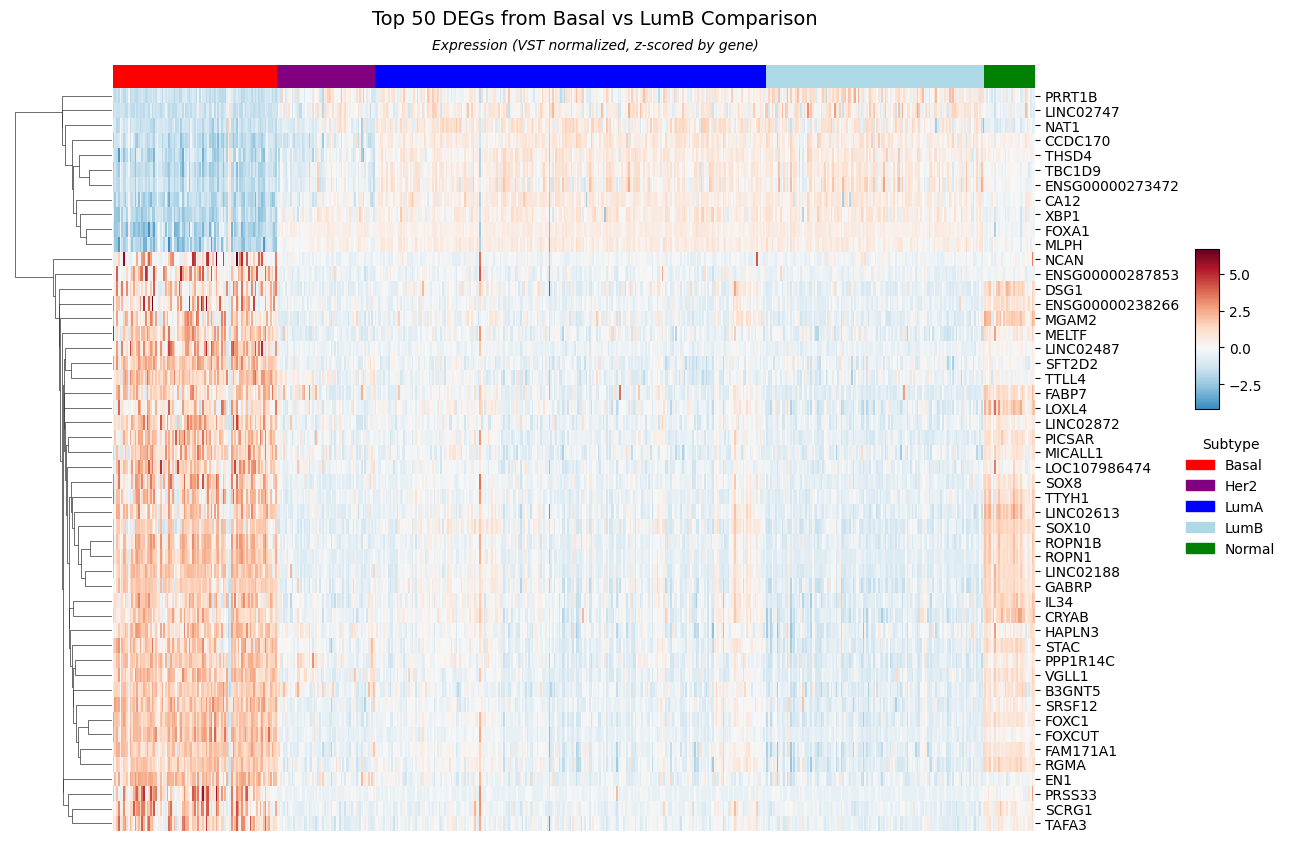

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


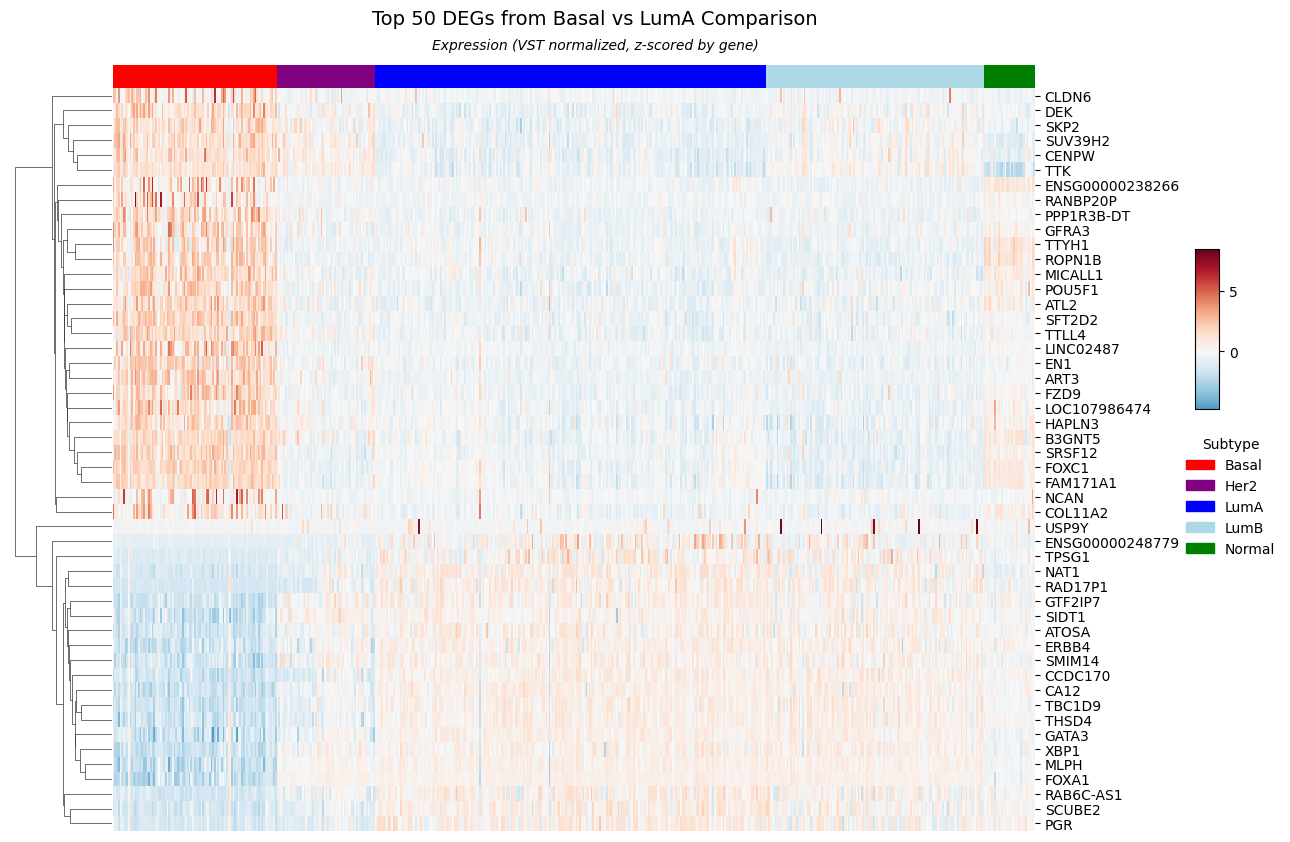

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


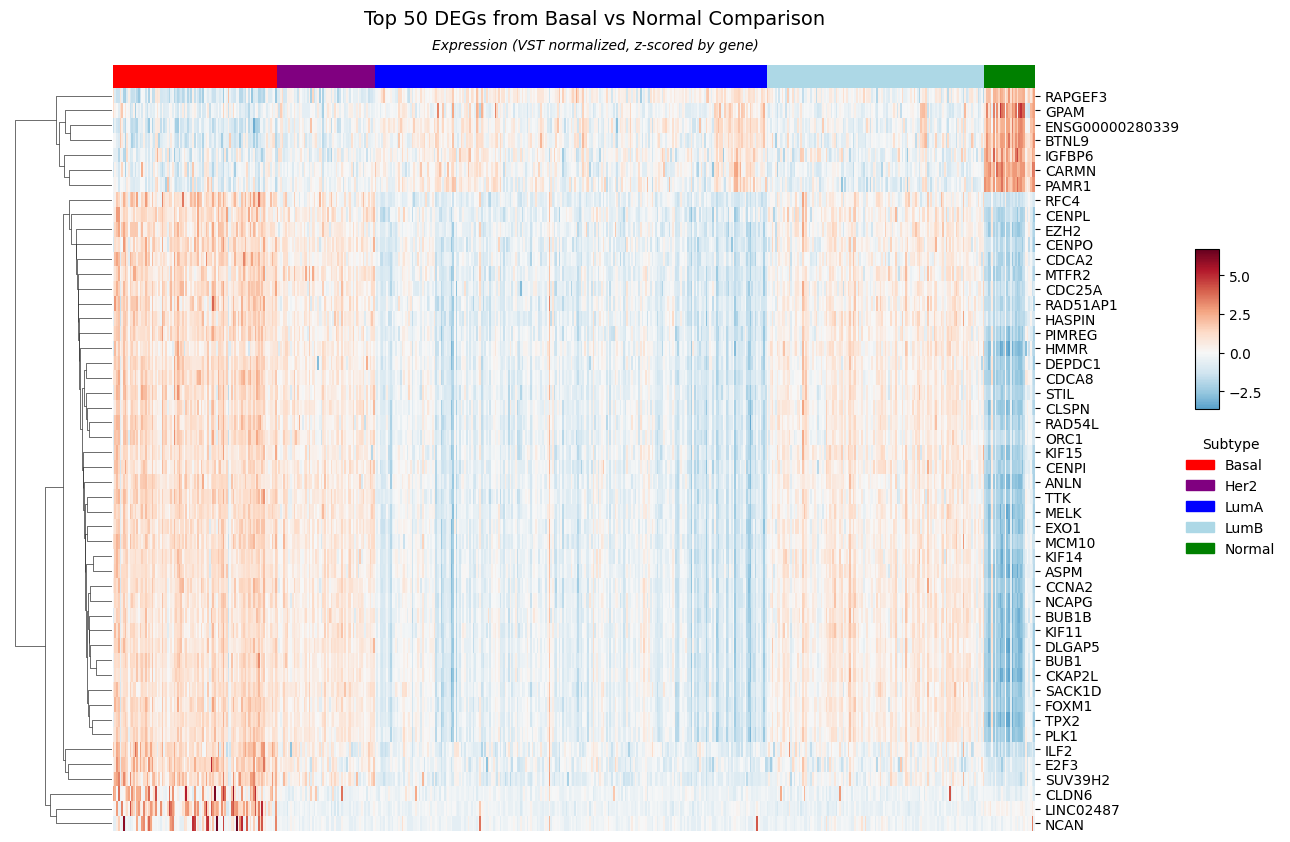

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


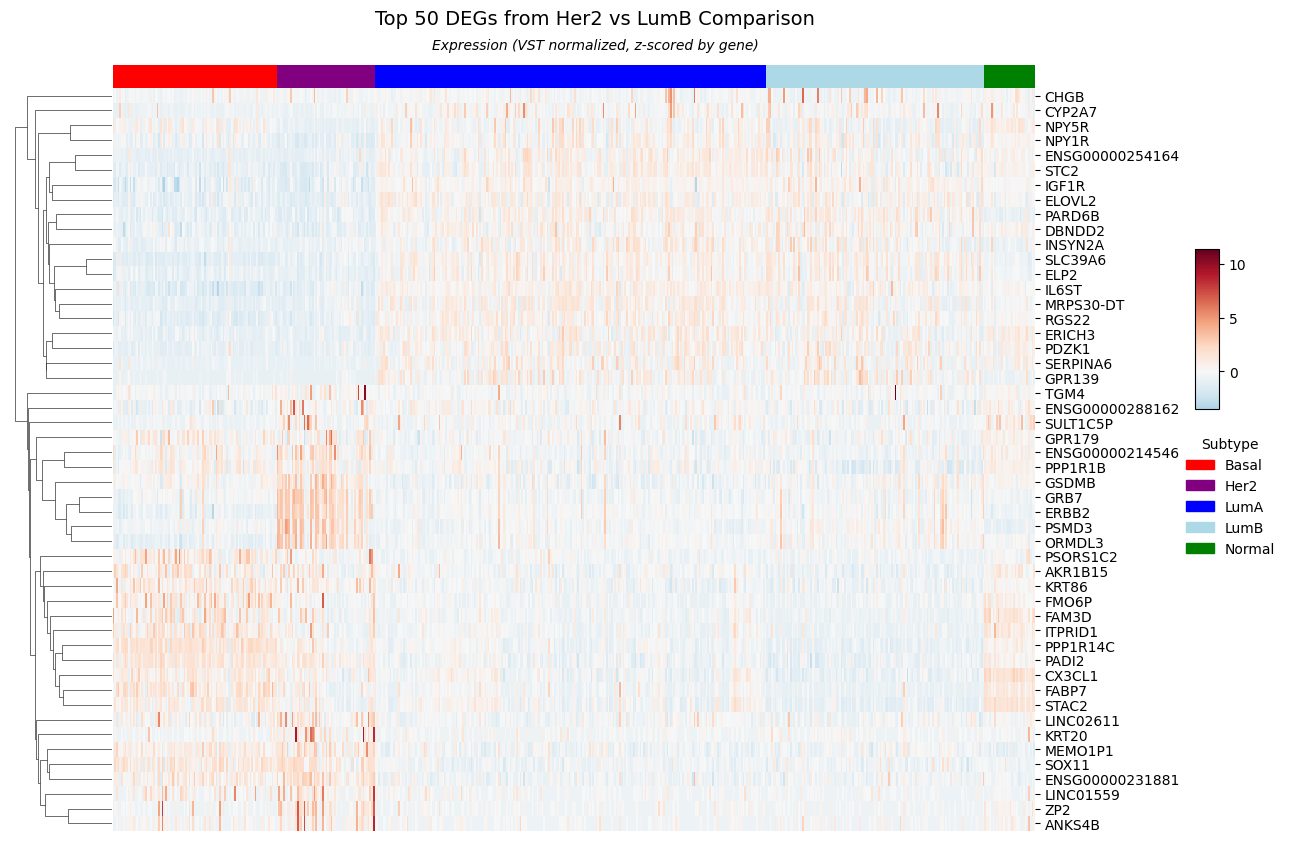

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


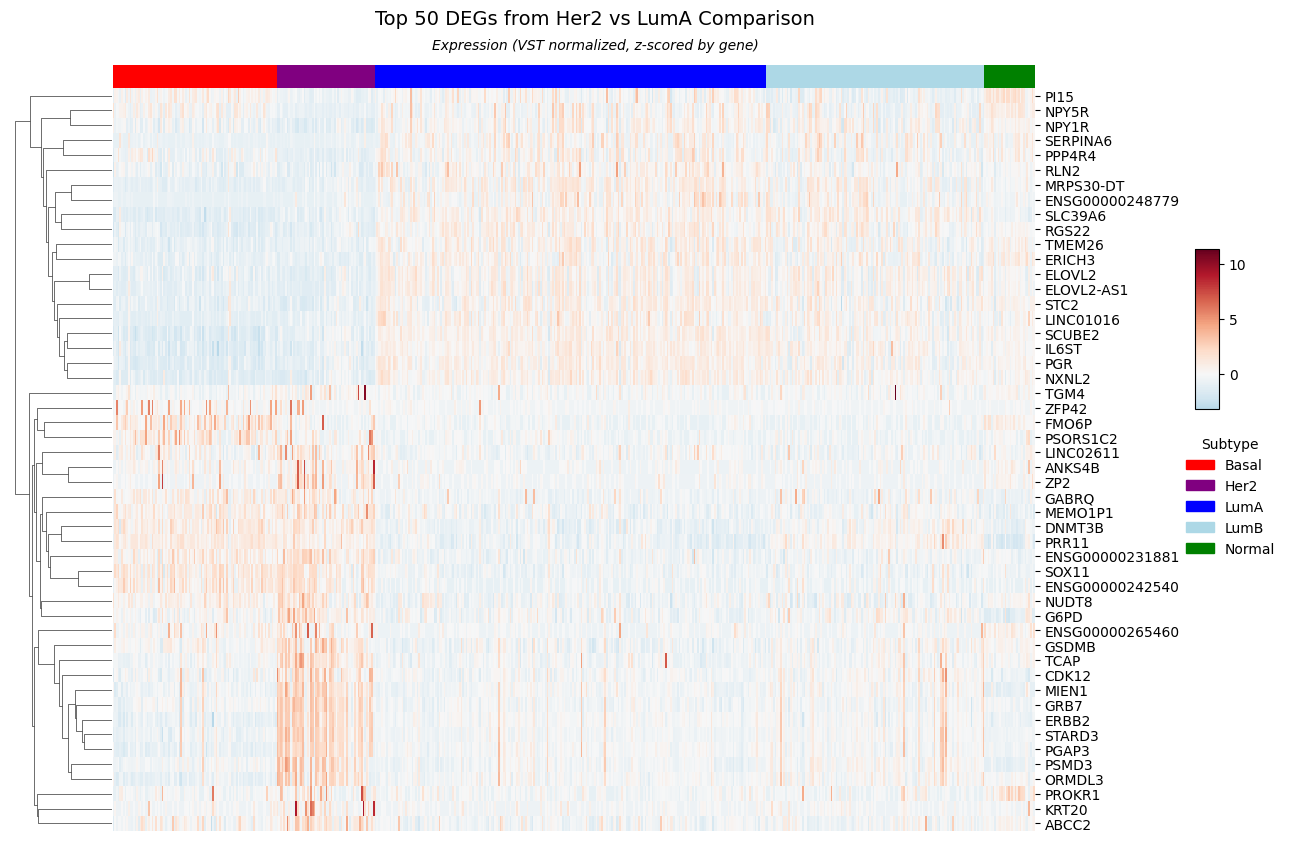

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


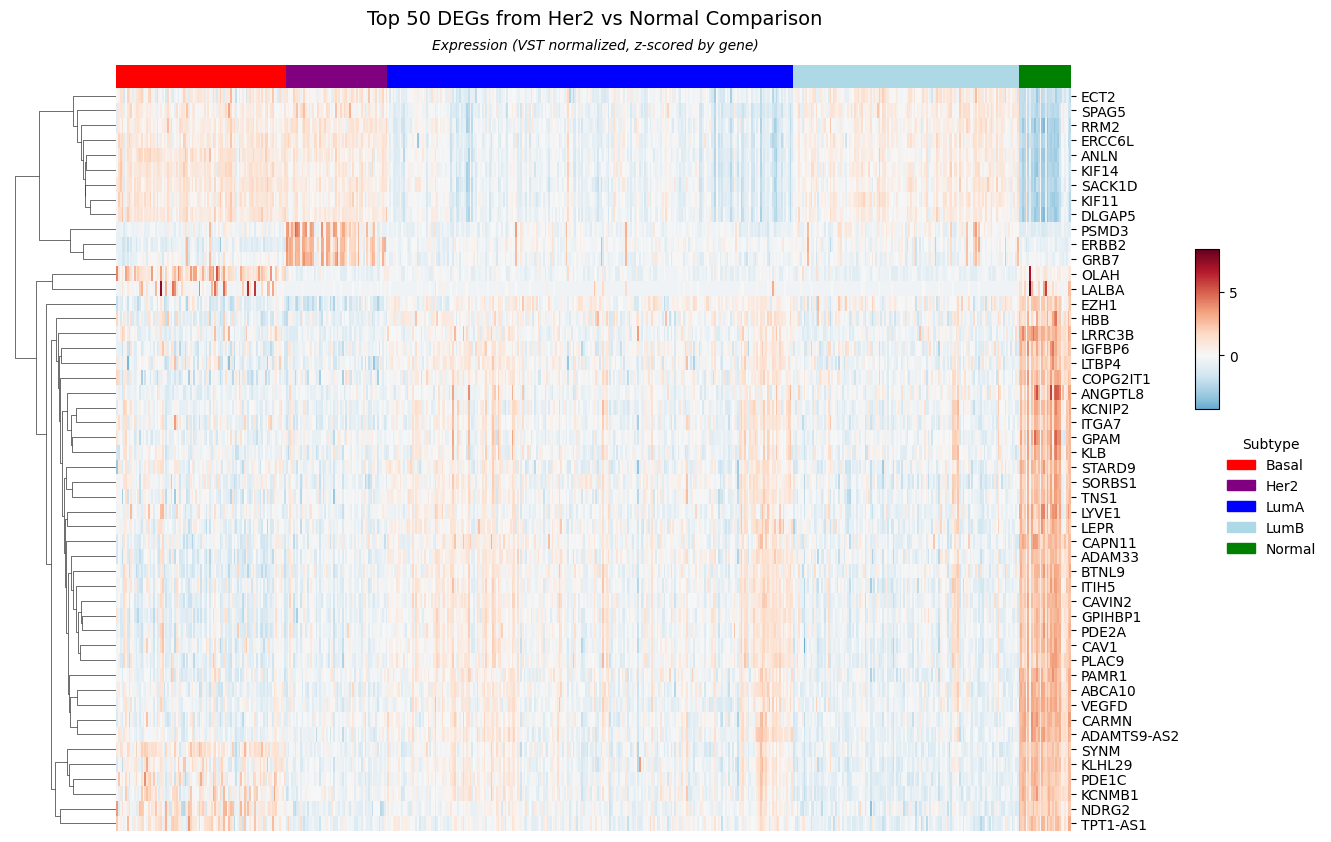

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


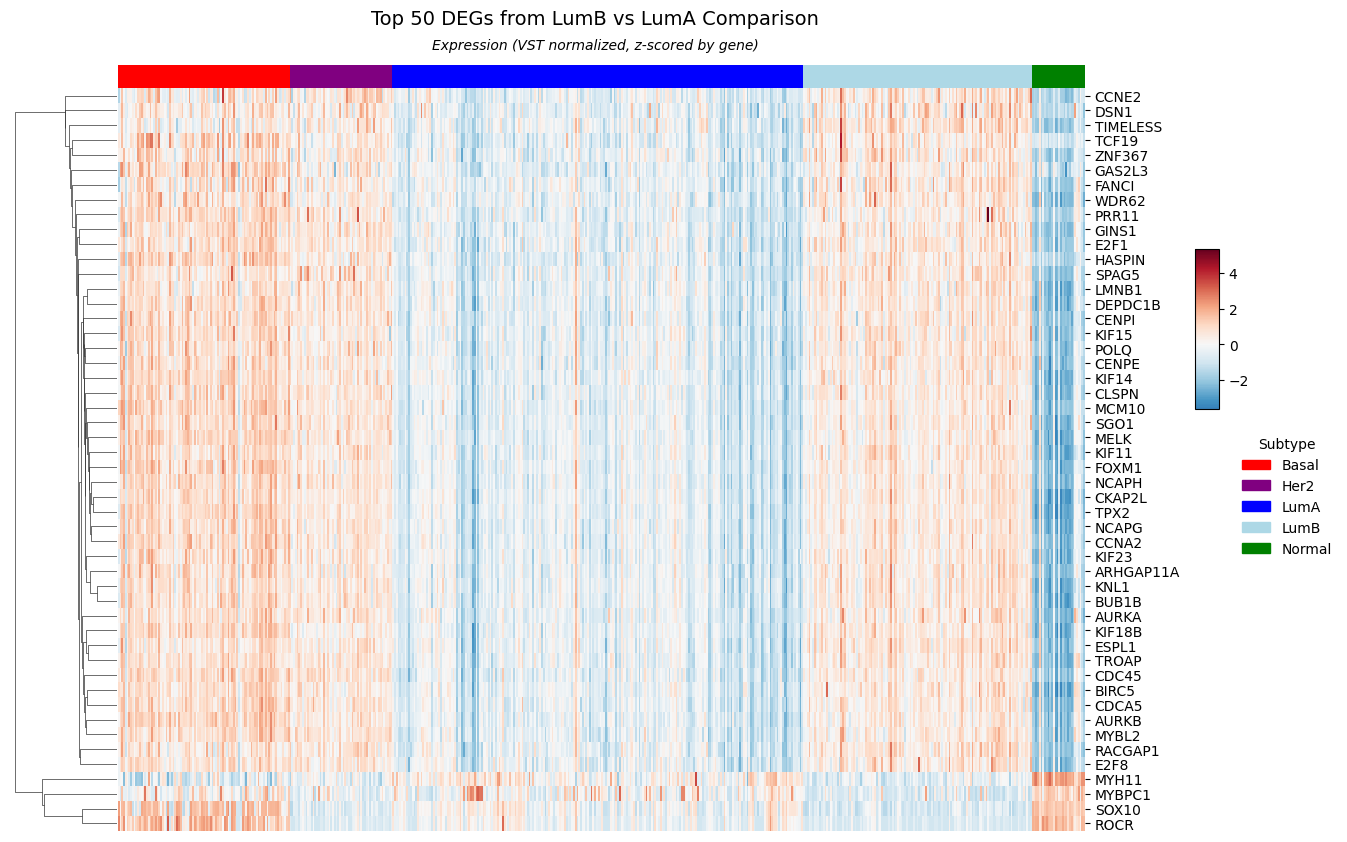

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


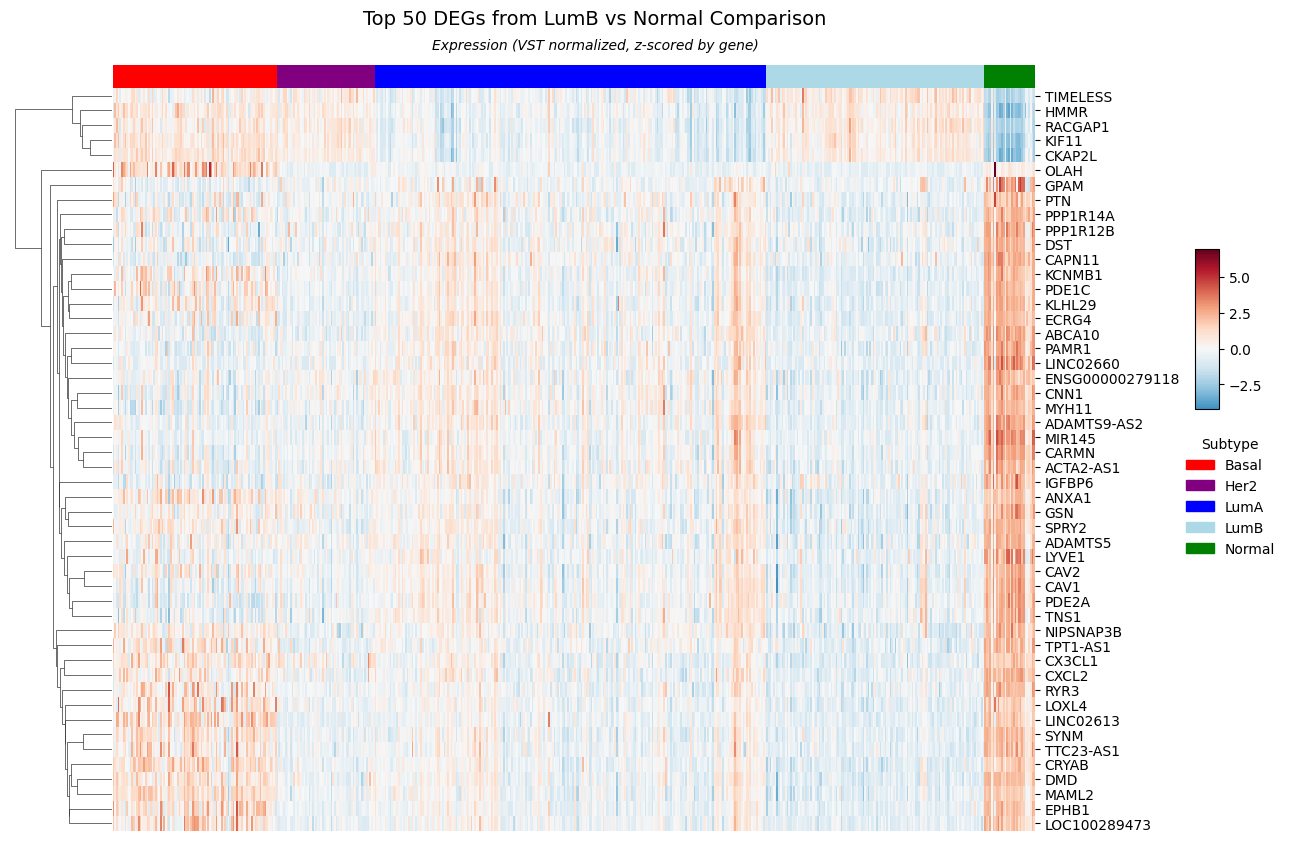

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


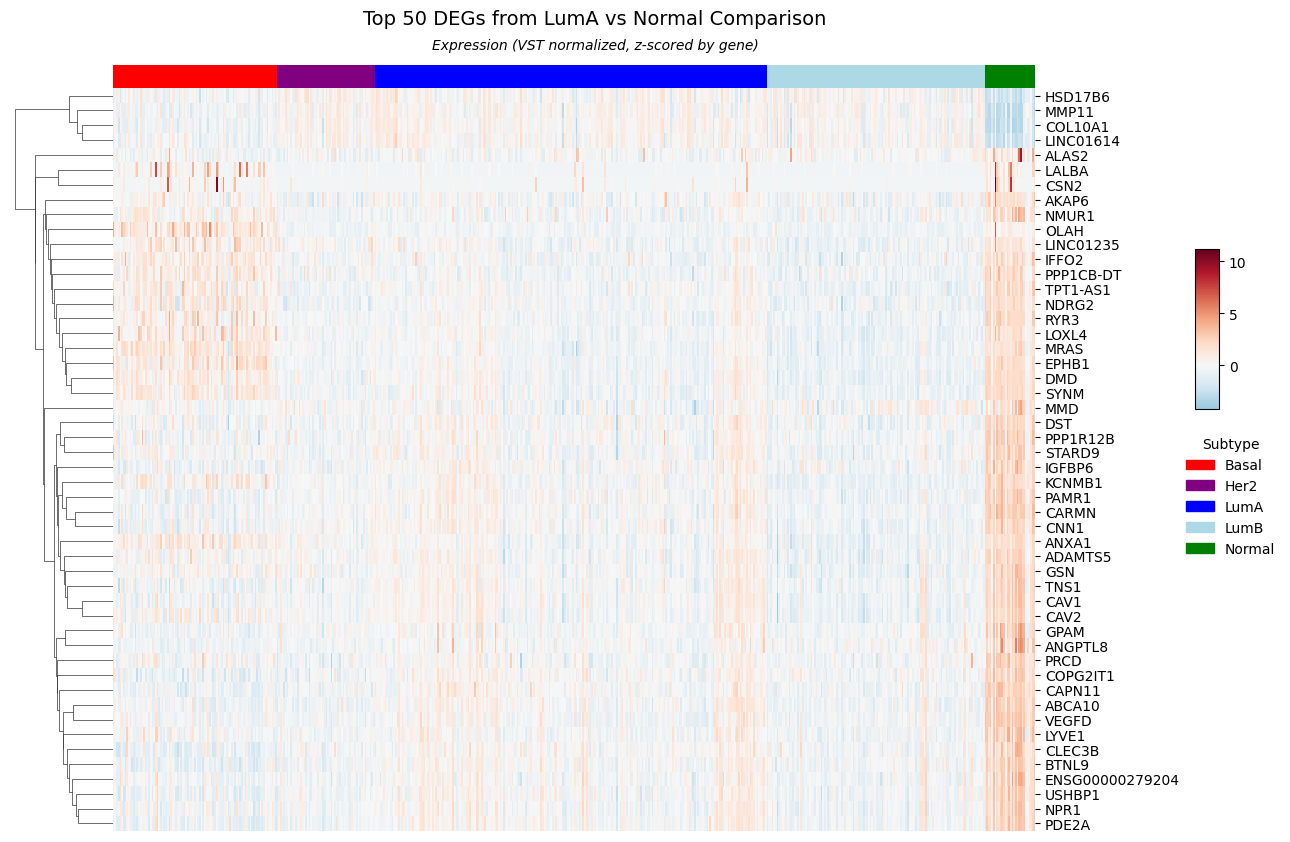

In [244]:
for name, df in results.items():
    g = plot_heatmap(df, df_expression_vst, df_metadata, name.replace('_', ' '))
    
    if SAVE:
        g.savefig(f'{OUTPUT_PATH}/heatmap_{name}.png', dpi=150, bbox_inches='tight')

    plt.show()

# Save Results

In [248]:
for name, df in results.items():
    # Save full results
    df.to_csv(f'{OUTPUT_PATH}/full/{name}_full.csv')

    # Save significant DEGs
    sig = df[(df['padj'] < 0.05) & (df['log2FoldChange'].abs() > 1)]
    sig.to_csv(f'{OUTPUT_PATH}/significant/{name}_significant.csv')

    # Split into up and down regulated genes
    up = sig[sig['log2FoldChange'] > 0]
    down = sig[sig['log2FoldChange'] < 0]
    up.to_csv(f'{OUTPUT_PATH}/up/{name}_up.csv')
    down.to_csv(f'{OUTPUT_PATH}/down/{name}_down.csv')

    print(f'{name}: {len(sig)} significant ({len(up)} up, {len(down)} down)')

Basal_vs_Her2: 5418 significant (3078 up, 2340 down)
Basal_vs_LumB: 6966 significant (4041 up, 2925 down)
Basal_vs_LumA: 7531 significant (4415 up, 3116 down)
Basal_vs_Normal: 7521 significant (3839 up, 3682 down)
Her2_vs_LumB: 3183 significant (1756 up, 1427 down)
Her2_vs_LumA: 3953 significant (2113 up, 1840 down)
Her2_vs_Normal: 7420 significant (3292 up, 4128 down)
LumB_vs_LumA: 1711 significant (770 up, 941 down)
LumB_vs_Normal: 7268 significant (3076 up, 4192 down)
LumA_vs_Normal: 5319 significant (2111 up, 3208 down)
